## Лабораторная 4: Классификация на датасете Smart Healthcare

**Цель:** сравнить 3 модели классификации (логистическая регрессия, SVM, дерево решений) на датасете `smart_healthcare_dataset.csv`, оценить качество двумя метриками, вывести важность признаков и визуализировать/получить правила дерева решений.

**Целевая переменная:** `heart_disease` (0/1).

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
plt.style.use("seaborn-v0_8")

In [2]:
DATA_PATH = "smart_healthcare_dataset.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,age,gender,bmi,exercise_level,smoking,alcohol,blood_pressure,cholesterol,glucose,fatigue,chest_pain,dizziness,heart_disease,diabetes,stroke,health_risk_score
0,56,Male,22.6,2,1,1,169,225,74,0,1,0,0,0,0,100.0
1,69,Female,28.2,0,1,1,136,230,198,0,1,0,1,1,1,100.0
2,46,Female,25.1,1,0,1,142,221,89,0,1,1,0,0,0,100.0
3,32,Female,18.0,0,0,1,173,296,152,1,0,0,0,0,0,100.0
4,60,Female,20.1,2,1,0,130,292,133,1,1,1,0,1,0,100.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                5000 non-null   int64  
 1   gender             5000 non-null   object 
 2   bmi                5000 non-null   float64
 3   exercise_level     5000 non-null   int64  
 4   smoking            5000 non-null   int64  
 5   alcohol            5000 non-null   int64  
 6   blood_pressure     5000 non-null   int64  
 7   cholesterol        5000 non-null   int64  
 8   glucose            5000 non-null   int64  
 9   fatigue            5000 non-null   int64  
 10  chest_pain         5000 non-null   int64  
 11  dizziness          5000 non-null   int64  
 12  heart_disease      5000 non-null   int64  
 13  diabetes           5000 non-null   int64  
 14  stroke             5000 non-null   int64  
 15  health_risk_score  5000 non-null   float64
dtypes: float64(2), int64(13)

In [4]:
# Проверим пропуски
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0].head(20)

Series([], dtype: int64)

In [5]:
target = "heart_disease"

X = df.drop(columns=[target])
y = df[target]

print("Размер X:", X.shape)
print("Доли классов y:")
print(y.value_counts(normalize=True).rename("share").to_frame().join(y.value_counts().rename("count")))

Размер X: (5000, 15)
Доли классов y:
                share  count
heart_disease               
0              0.7002   3501
1              0.2998   1499


In [6]:
# Выделим типы признаков
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = [c for c in X.columns if c not in categorical_features]

categorical_features, numeric_features[:5], len(numeric_features)

(['gender'], ['age', 'bmi', 'exercise_level', 'smoking', 'alcohol'], 14)

In [7]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_train.shape, X_test.shape

((4000, 15), (1000, 15))

In [8]:
# Предобработка: заполнение пропусков + OHE для категорий + стандартизация числовых
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

In [9]:
# Модели
models = {
    "LogReg": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "SVM(RBF)": SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced", random_state=42),
    "DecisionTree": DecisionTreeClassifier(max_depth=5, random_state=42, class_weight="balanced"),
}

pipelines = {
    name: Pipeline(steps=[("preprocess", preprocess), ("model", model)])
    for name, model in models.items()
}

pipelines

{'LogReg': Pipeline(steps=[('preprocess',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['age', 'bmi',
                                                    'exercise_level', 'smoking',
                                                    'alcohol', 'blood_pressure',
                                                    'cholesterol', 'glucose',
                                                    'fatigue', 'chest_pain',
                                                    'dizziness', 'diabetes',
                                                    'stroke',
                             

In [10]:
def evaluate_binary_classifier(pipe, X_train, y_train, X_test, y_test):
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "report": classification_report(y_test, y_pred, digits=3),
    }

results = {}
for name, pipe in pipelines.items():
    results[name] = evaluate_binary_classifier(pipe, X_train, y_train, X_test, y_test)

pd.DataFrame({
    name: {"accuracy": res["accuracy"], "f1": res["f1"]}
    for name, res in results.items()
}).T.sort_values(["f1", "accuracy"], ascending=False)

,accuracy,f1
LogReg,0.991,0.985173
SVM(RBF),0.967,0.945455
DecisionTree,0.955,0.928685


In [11]:
# Подробный отчёт по лучшей модели по F1
best_name = max(results.keys(), key=lambda k: results[k]["f1"])
print("Лучшая модель по F1:", best_name)
print(results[best_name]["report"])
print("Confusion matrix:\n", results[best_name]["confusion_matrix"])

Лучшая модель по F1: LogReg
              precision    recall  f1-score   support

           0      0.999     0.989     0.994       700
           1      0.974     0.997     0.985       300

    accuracy                          0.991      1000
   macro avg      0.986     0.993     0.989      1000
weighted avg      0.991     0.991     0.991      1000

Confusion matrix:
 [[692   8]
 [  1 299]]


/var/folders/46/wb3675_x67d30mb_d811zhhc0000gn/T/ipykernel_8768/1029968353.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi.head(15), x="importance", y="feature", palette="viridis")


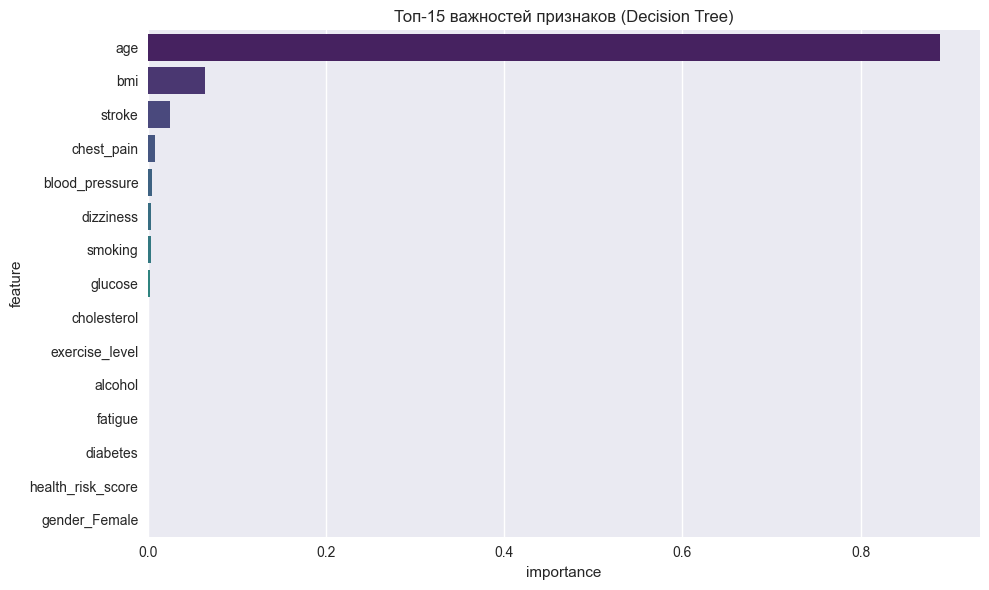

,feature,importance
0,age,8.896054e-01
1,bmi,6.380789e-02
12,stroke,2.500878e-02
9,chest_pain,7.553025e-03
5,blood_pressure,4.880597e-03
10,dizziness,3.646397e-03
3,smoking,3.370727e-03
7,glucose,1.760519e-03
6,cholesterol,3.666710e-04
2,exercise_level,2.536501e-16


In [12]:
# Важность признаков в дереве решений
# (важности доступны только для модели дерева; возьмём обученный пайплайн)

tree_pipe = pipelines["DecisionTree"].fit(X_train, y_train)

# Достаём имена признаков после преобразований
pre = tree_pipe.named_steps["preprocess"]

feature_names = []
# Числовые
feature_names.extend(numeric_features)
# Категориальные (one-hot)
if categorical_features:
    ohe = pre.named_transformers_["cat"].named_steps["onehot"]
    ohe_names = ohe.get_feature_names_out(categorical_features).tolist()
    feature_names.extend(ohe_names)

importances = tree_pipe.named_steps["model"].feature_importances_
fi = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi.head(15), x="importance", y="feature", palette="viridis")
plt.title("Топ-15 важностей признаков (Decision Tree)")
plt.tight_layout()
plt.show()

fi.head(15)

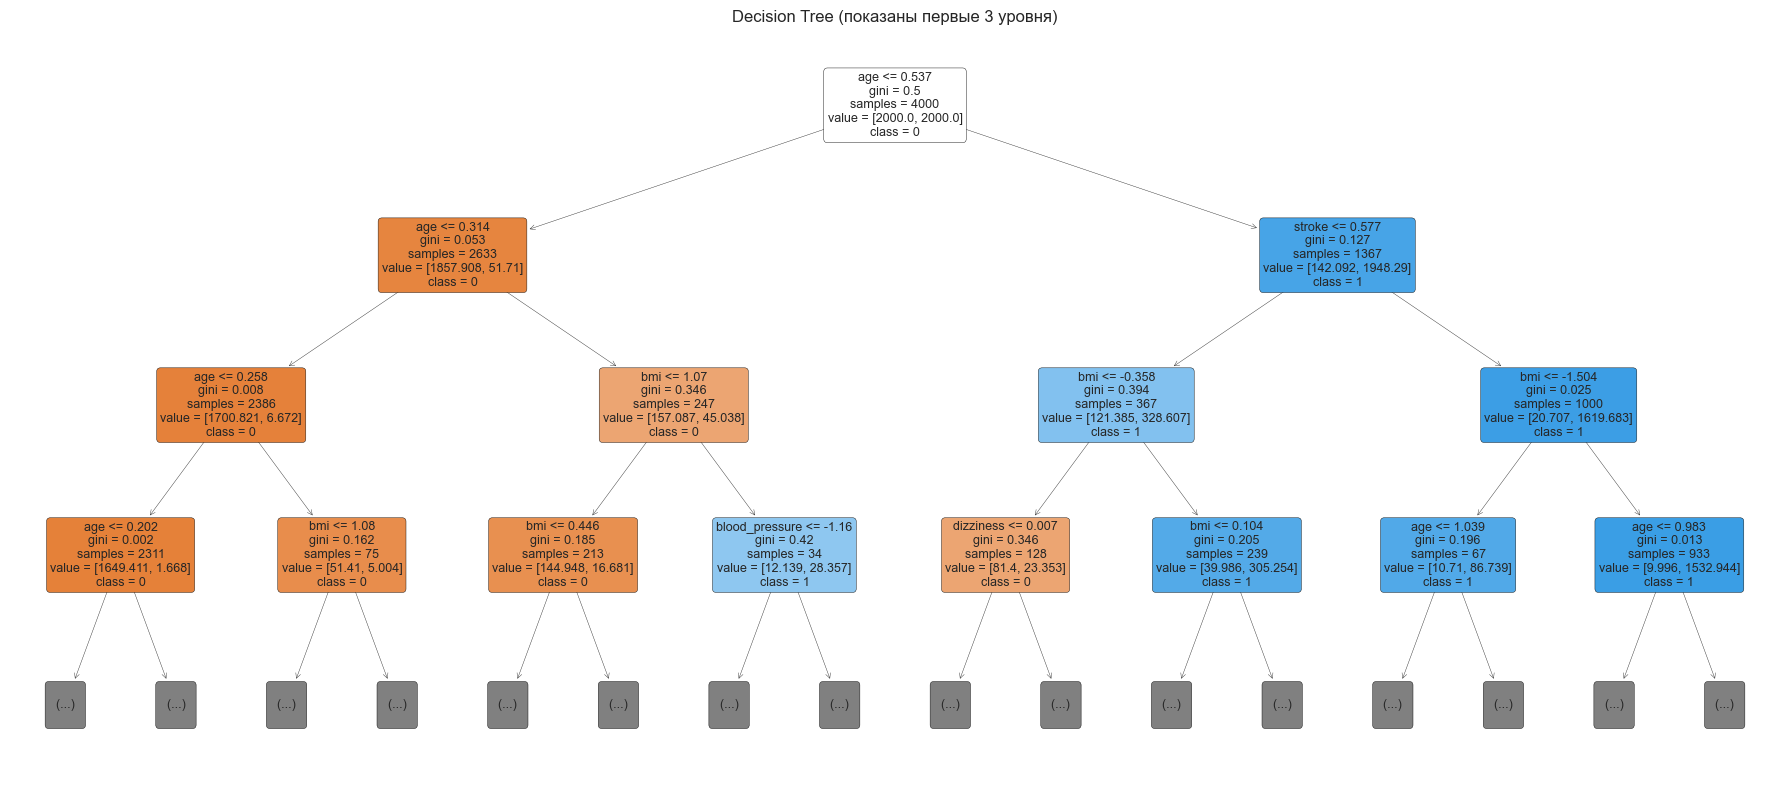

In [13]:
# Визуализация дерева решений (ограничим глубину на графике для читаемости)
clf = tree_pipe.named_steps["model"]

plt.figure(figsize=(18, 8))
plot_tree(
    clf,
    feature_names=feature_names,
    class_names=["0", "1"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9,
)
plt.title("Decision Tree (показаны первые 3 уровня)")
plt.tight_layout()
plt.show()

In [14]:
# Правила дерева в текстовом виде
rules = export_text(clf, feature_names=feature_names, max_depth=5)
print(rules[:4000])  # ограничим вывод, чтобы не засорять ноутбук

|--- age <= 0.54
|   |--- age <= 0.31
|   |   |--- age <= 0.26
|   |   |   |--- age <= 0.20
|   |   |   |   |--- class: 0
|   |   |   |--- age >  0.20
|   |   |   |   |--- bmi <= 1.82
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- bmi >  1.82
|   |   |   |   |   |--- class: 1
|   |   |--- age >  0.26
|   |   |   |--- bmi <= 1.08
|   |   |   |   |--- class: 0
|   |   |   |--- bmi >  1.08
|   |   |   |   |--- glucose <= -0.37
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- glucose >  -0.37
|   |   |   |   |   |--- class: 1
|   |--- age >  0.31
|   |   |--- bmi <= 1.07
|   |   |   |--- bmi <= 0.45
|   |   |   |   |--- cholesterol <= 0.85
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- cholesterol >  0.85
|   |   |   |   |   |--- class: 0
|   |   |   |--- bmi >  0.45
|   |   |   |   |--- smoking <= -0.03
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- smoking >  -0.03
|   |   |   |   |   |--- class: 1
|   |   |--- bmi >  1.07
|   |   |   |--- blood_pressure <= 

### Вывод

- **Предобработка**: пропуски заполняются (числовые — медианой, категориальные — модой), `gender` кодируется One-Hot, числовые признаки стандартизируются.
- **Оценка качества**: использованы **Accuracy** и **F1-score** (уместно при дисбалансе классов).
- **Сравнение моделей**: см. таблицу метрик выше.
- **Интерпретация дерева**: показаны **важности признаков**, **визуализация дерева** (первые уровни) и **правила** в текстовом виде.